## Reducción del modelo completo de Hodgkin-Huxley

En esta sección se considera el modelo completo de Hodgkin-Huxley para una única neurona, descripto por cuatro variables dinámicas: el voltaje de membrana $V$ y las variables de compuerta $m$, $h$ y $n$.

A partir de la simulación temporal del sistema, se analiza la relación entre las variables de activación e inactivación, observándose que la suma $n(t) + h(t)$ se mantiene aproximadamente constante a lo largo del tiempo. Esta propiedad permite reducir la dimensionalidad del sistema, expresando una de las variables en función de la otra.

Utilizando esta aproximación, se construye un modelo reducido de dos variables ($V$ y $n$), en el cual se reemplaza $h$ por $\alpha - n$, donde $\alpha$ corresponde al valor medio de $n+h$ obtenido numéricamente.

Se comparan las soluciones del modelo completo y del modelo reducido, mostrando que este último reproduce adecuadamente la dinámica del voltaje.


In [23]:
from math import *
from pylab import *
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import time
from scipy.signal import argrelextrema
from scipy.fft import fft, ifft
from scipy.optimize import fsolve
from scipy.integrate import odeint
import time

In [24]:
start_time = time.time()

#KSE = int(input("Ingresá un número de caso: "))
KSE = 1
                # 1: Single cell   
                # 2: Two-cell network. simula una red de dos neuronas acopladas mediante sinapsis inhibitorias. Cada neurona sigue el modelo de Hodgkin-Huxley completo (como en KSE == 1), pero con una variable adicional por neurona (Si1 y Si2) que representa la corriente sináptica
                # 3: Two-cell network, reduced cellu model



# Functions

#es lo mismo que tener def minf(v):
#    return 1 / (1 + np.exp(-(v + 40) / 9)) (La sintaxis lambda es de Python)
minf = lambda v: 1 / (1 + np.exp(-(v + 40) / 9))  #Representa la activación de los canales de sodio (𝑚_∞).Es la probabilidad de que las "puertas de activación" estén abiertas, permitiendo que los iones de sodio (𝑁𝑎+) entren y despolaricen la membrana (suban el voltaje).
hinf = lambda v: 1 / (1 + np.exp((v + 62) / 10)) #Representa la inactivación de los canales de sodio (ℎ∞ ). Es la probabilidad de que las "puertas de inactivación" estén cerradas, bloqueando la entrada de sodio para limitar el potencial de acción.
ninf = lambda v: 1 / (1 + np.exp(-(v + 53) / 16)) #Calcula la probabilidad de activación de los canales de potasio (𝑛_∞) en equilibrio.
taum = lambda v: 0.3 + 1e-12 * v #Define la constante de tiempo (en ms) para la activación de los canales de sodio (m).
tauh = lambda v: 1 + 11 / (1 + np.exp((v + 62) / 10)) #Define la constante de tiempo (en ms) para la inactivación de los canales de sodio (h).
taun = lambda v: 1 + 6 / (1 + np.exp((v + 53) / 16)) #Define la constante de tiempo (en ms) para la activación de los canales de potasio (n).
H = lambda v: 0.5 * (1 + np.tanh((v + 0) / 4)) #Calcula la probabilidad de activación sináptica basada en el voltaje presináptico. Representa cómo una neurona presináptica activa la sinapsis hacia otra neurona.
#Sinf = lambda v: 0.5 * (1 + np.tanh((v + 0) / 4)) #PARECE ESTAR DE MÁS


Fa = lambda v, n, Iapp, Gl, Gna, Gk: (
    (Iapp - Gl * (v - El) - Gna * minf(v)**3 * (alpha - n) * (v - Ena) - Gk * n**4 * (v - Ek)) / C
)  #La función Fa calcula la tasa de cambio del voltaje (𝑑𝑣/𝑑𝑡) en un modelo reducido, sumando la corriente externa (Iapp), la corriente de fuga, y las corrientes de sodio y potasio, divididas por la capacitancia (C). Representa cómo el voltaje evoluciona para generar spikes.


# Biophysical parameters
C = 1;  #Representa la capacidad de la membrana para almacenar carga, como un condensador. Un valor de 1 μF/cm² es típico en neuronas. Determina qué tan rápido responde el voltaje a las corrientes, afectando la forma del spike.
El = -65; #Es el potencial de equilibrio de la corriente de fuga, en mV. Mantiene la neurona en un estado estable cuando no hay estímulos.
Ena = 55; #Potencial de equilibrio del sodio, en mV. La diferencia  𝑣−𝐸_𝑁𝑎  impulsa la entrada de 𝑁𝑎+, iniciando el spike.
Ek = -75; #Potencial de equilibrio del potasio, en mV.  La diferencia 𝑣−𝐸_𝑘  impulsa la salida de 𝐾+, repolarizando la membrana tras el spike.
Gl = 0.025; #Conductancia de la corriente de fuga, en mS/cm². Estabiliza el voltaje en reposo, contrarrestando corrientes excitatorias.
Gna = 120; # Conductancia máxima de los canales de sodio, en mS/cm². Es clave para generar el ascenso rápido del spike.
Gk = 36; # Conductancia máxima de los canales de potasio, en mS/cm². Es esencial para la repolarización (bajada del voltaje) tras el spike.
Iapp = 3.5; #Corriente externa aplicada, en μA/cm². Inicia los potenciales de acción.. #chequear que se tiene q dejar fijo


taurse_i = 0.3;  #Constante de tiempo de subida de la corriente sináptica, en ms. Significado: Indica qué tan rápido se activa la corriente sináptica cuando una neurona presináptica genera un spike. Un valor pequeño (0.3 ms) implica una activación rápida.
taudec_i = 9.0; #Constante de tiempo de decaimiento de la corriente sináptica, en ms. Significado: Indica qué tan rápido decae la corriente sináptica tras la activación. Un valor mayor (9 ms) implica un decaimiento lento.
Ein = -80; #Potencial de equilibrio de la corriente sináptica, en mV. Significado: Es el voltaje al que la corriente sináptica no fluye. Negativo (-80 mV) indica una sinapsis inhibitoria (probablemente GABAérgica).

Gin12 = 0.08; #Conductancia sináptica de la neurona 1 a la neurona 2, en mS/cm². Significado: Mide la fuerza de la conexión sináptica de la neurona 1 (presináptica) a la neurona 2 (postsináptica).
Gin21 = Gin12; #Conductancia sináptica de la neurona 2 a la neurona 1, en mS/cm². Significado: idem


# Activation inactivation curves

vv = np.arange(-100, 100.1, 0.1)  #np.arange(start, stop, step) genera un arreglo de valores desde start hasta stop (sin incluirlo), con incrementos de step.
#Aquí: vv contiene voltajes de -100 mV a 100 mV, con pasos de 0.1 mV.

'''
# Primera figura: curvas de activación e inactivación. muestra cómo los canales de sodio (minf, hinf) y potasio (ninf) se abren/cierran, iniciando y terminando los spikes.
plt.figure()
plt.plot(vv, minf(vv), 'b', linewidth=2, label=r'$m_{\infty}$')
plt.plot(vv, hinf(vv), 'r', linewidth=2, label=r'$h_{\infty}$')
plt.plot(vv, ninf(vv), 'g', linewidth=2, label=r'$n_{\infty}$')
plt.xlim([-100, 120])
plt.ylim([-0.1, 1.1])
plt.xlabel('V', fontsize=16)
plt.legend(fontsize=16)
plt.grid(True)
plt.tick_params(labelsize=14)

# Segunda figura: constantes de tiempo. muestra la velocidad de esos procesos (taum, tauh, taun), que determina la forma y duración de los spikes.
plt.figure()
plt.plot(vv, taum(vv), 'b', linewidth=2, label=r'$\tau_m$')
plt.plot(vv, tauh(vv), 'r', linewidth=2, label=r'$\tau_h$')
plt.plot(vv, taun(vv), 'g', linewidth=2, label=r'$\tau_n$')
plt.xlim([-100, 120])
plt.ylim([-0.1, 12])
plt.xlabel('V', fontsize=16)
plt.legend(fontsize=16)
plt.grid(True)
plt.tick_params(labelsize=14)

'''

'''
#Método de Runge-Kutta 4
def rk4_step(f, y, t, dt):
    k1 = f(y, t)
    k2 = f(y + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(y + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(y + dt * k3, t + dt)
    return y + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
'''

def rk4_step(f, y, t, dt): #(En realidad es RK2 pero use mismo nombre para q sea mas facil)
    k1 = f(y, t)
    k2 = f(y + dt * k1, t + dt)
    return y + (dt / 2) * (k1 + k2)
    

if KSE == 1:
    # Time definitions
    Tmax = 1000
    dt = 0.01
    t = np.arange(0, Tmax + dt, dt)


    # MODELO COMPLETO_____________________________________________________________________________________________________________________________________________
    # Derivadas del sistema
    def full_model_deriv(state, t):
        V, m, h, n = state
        dVdt = (Iapp - Gl * (V - El) - Gna * m**3 * h * (V - Ena) - Gk * n**4 * (V - Ek)) / C
        dmdt = (minf(V) - m) / taum(V)
        dhdt = (hinf(V) - h) / tauh(V)
        dndt = (ninf(V) - n) / taun(V)
        return np.array([dVdt, dmdt, dhdt, dndt])


    Y = np.zeros((len(t), 4))  # columnas: V, m, h, n. Esto crea una matriz de ceros de tamaño (len(t), 4). Cada fila representa el estado del sistema en un instante de tiempo.
    #Cada columna representa una de las 4 variables del modelo de Hodgkin-Huxley completo: Y[:, 0] → 𝑉, Y[:, 1] → 𝑚, Y[:, 2] → ℎ, Y[:, 3] → 𝑛

    Y[0, :] = [-65, 0, 0, 0]  # condiciones iniciales. El voltaje arranca en -65 mV, que es potencial de reposo.
    #Los valores de 𝑚,ℎ,𝑛 se inicializan en sus valores de equilibrio para 𝑉=−65, usando las funciones minf, hinf, ninf.

    for i in range(1, len(t)):
        Y[i] = rk4_step(full_model_deriv, Y[i-1], t[i-1], dt) 

    Vo = Y[:, 0].copy()
    var_m = Y[:,1]
    var_h = Y[:,2]
    var_n = Y[:,3]

    '''
    #Grafico del modelo completo
    plt.figure()
    plt.plot(t, Vo, 'b', linewidth=2)
    plt.axis([0, Tmax, -80, 80])
    plt.xlabel('time [ms]')
    plt.ylabel('Membrane Potential [mV]')
    plt.legend(['V original'])
    plt.grid()
    plt.tick_params(labelsize=16)


    #Grafico de la proyeccion nh
    #Grafico de la proyeccion nh
    plt.figure()
    plt.plot(var_n[2000:9000],var_h[2000:9000],'blue', linewidth=2)
    x = np.linspace(0, 1, 200)
    m = -1
    b= np.mean(var_n+var_h)
    y = m*x + b
    plt.plot(x, y,'--r',label=f'n+h = {b:.2f}')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('n')
    plt.ylabel('h')
    plt.legend()


    #n+h=0.86
    plt.figure(figsize=(16, 4))
    plt.axis([0, 100, 0, 1.6])
    plt.plot(t, var_n + var_h, 'g', linewidth=1)

    alpha = np.mean(var_n + var_h)
    plt.axhline(y=alpha, color='r', linestyle='--')

    # Agregar alpha como marca en el eje Y
    yticks = list(plt.yticks()[0])   # ticks actuales
    yticks.append(alpha)
    plt.yticks(sorted(yticks))

    plt.xlabel('time [ms]')
    plt.ylabel('n+h')

    '''
    #MODELO REDUCIDO________________________________________________________________________________________________________________________________________________
    alpha = mean(var_n+var_h)
    

    # Derivadas del sistema
    def reduced_model_deriv(state, t):
        V, n = state
        dVdt = (Iapp - Gl * (V - El) - Gna * minf(V)**3 * (alpha - n) * (V - Ena) - Gk * n**4 * (V - Ek)) / C
        dndt = (ninf(V) - n) / taun(V)
        return np.array([dVdt, dndt])

    Y_red = np.zeros((len(t), 2))  # columnas: V, n
    Y_red[0, :] = [-65, 0]  # condiciones iniciales

    for i in range(1, len(t)):
        Y_red[i] = rk4_step(reduced_model_deriv, Y_red[i-1], t[i-1], dt)

    '''
    #Grafico del modelo reducido vs completo
    plt.figure()
    plt.plot(t, Vo, 'b', linewidth=2)
    plt.plot(t, Y_red[:, 0], 'r', linewidth=2)
    plt.axis([0, Tmax, -80, 80])
    plt.xlabel('time [ms]')
    plt.ylabel('Membrane Potential [mV]')
    plt.legend(['Full Model', 'Reduced Model'])
    plt.grid()
    plt.tick_params(labelsize=16)
    
    #Grafico del modelo reducido
    plt.figure()
    plt.plot(t, Y_red[:, 0], 'b', linewidth=2)
    plt.axis([0, Tmax, -80, 80])
    plt.xlabel('time [ms]')
    plt.ylabel('Membrane Potential [mV]')
    plt.legend(['V reducida'])
    plt.grid()
    plt.tick_params(labelsize=16)
    

    #NULLCLINES __________________________________________________________________________________________________________________________________

    vv = np.arange(-100, 100.01, 0.01)
    nnlc = ninf(vv)

    # v-nullcline por ciclo límite
    vnlc = []

    A0 = Iapp - Gl * (vv - El) - Gna * minf(vv)**3 * alpha * (vv - Ena)
    A1 = Gna * minf(vv)**3 * (vv - Ena)
    A4 = -Gk * (vv - Ek)

    jincl = []

    for j in range(len(vv)):
        coeffs = [A0[j], A1[j], 0, 0, A4[j]]
        roots = np.roots(coeffs)
        real_roots = roots[np.isreal(roots)]
        if real_roots.size > 0:
            jincl.append(j)

    #CICLO LIMITE (Metodo Newton Raphson) __________________________________________________________________________________________________________________________
    f = lambda v, n: Iapp - Gl * (v - El) - Gna * minf(v)**3 * (alpha - n) * (v - Ena) - Gk * n**4 * (v - Ek)
    fn = lambda v, n: Gna * minf(v)**3 * (v - Ena) - 4 * Gk * n**3 * (v - Ek)

    #vnlc = []

    for j in range(jincl[0], jincl[-1]):
        v = vv[j]
        nold = 0.5
        nnew = nold - f(v, nold) / fn(v, nold)
        while abs(f(v, nnew)) > 0.001:
            nnew = nold - f(v, nold) / fn(v, nold)
            nold = nnew
        vnlc.append([v, nnew])

    vnlc = np.array(vnlc)

    plt.figure()
    plt.plot(vnlc[:, 0], vnlc[:, 1], 'r', linewidth=2)  # v-nullcline
    plt.plot(vv, nnlc, 'g', linewidth=2)  # n-nullcline
    plt.plot(Y_red[:, 0], Y_red[:, 1], 'b', linewidth=2)  # trayectoria
    plt.axis([-80, 60, 0, 1])
    plt.xlabel('V')
    plt.ylabel('n')
    plt.legend(['v_null', 'n_null', 'Trayectoria'])
    plt.grid()
    plt.tick_params(labelsize=16)
    '''
    

<>:57: SyntaxWarning: invalid escape sequence '\i'
<>:57: SyntaxWarning: invalid escape sequence '\i'
C:\Users\cordo\AppData\Local\Temp\ipykernel_27424\2425898539.py:57: SyntaxWarning: invalid escape sequence '\i'
  plt.plot(vv, minf(vv), 'b', linewidth=2, label=r'$m_{\infty}$')


## Dinámica temporal del modelo completo

En esta sección se muestra la evolución temporal de las variables principales del modelo.

En el primer panel se grafica el potencial de membrana $V(t)$, donde se observan los spikes generados por la dinámica neuronal.

En el segundo panel se representan las variables de activación e inactivación evaluadas en función del voltaje, $m_\infty(V(t))$, $h_\infty(V(t))$ y $n_\infty(V(t))$, lo que permite analizar cómo responden los canales iónicos a lo largo del tiempo.

En el tercer panel se grafica la suma $n(t) + h(t)$, que se mantiene aproximadamente constante. Este comportamiento justifica la reducción del modelo, en la cual una de las variables puede expresarse en función de la otra.

En conjunto, estas visualizaciones permiten comprender la relación entre la dinámica del voltaje y la evolución de las variables de compuerta, así como motivar el uso de un modelo reducido para el análisis en el plano de fases.


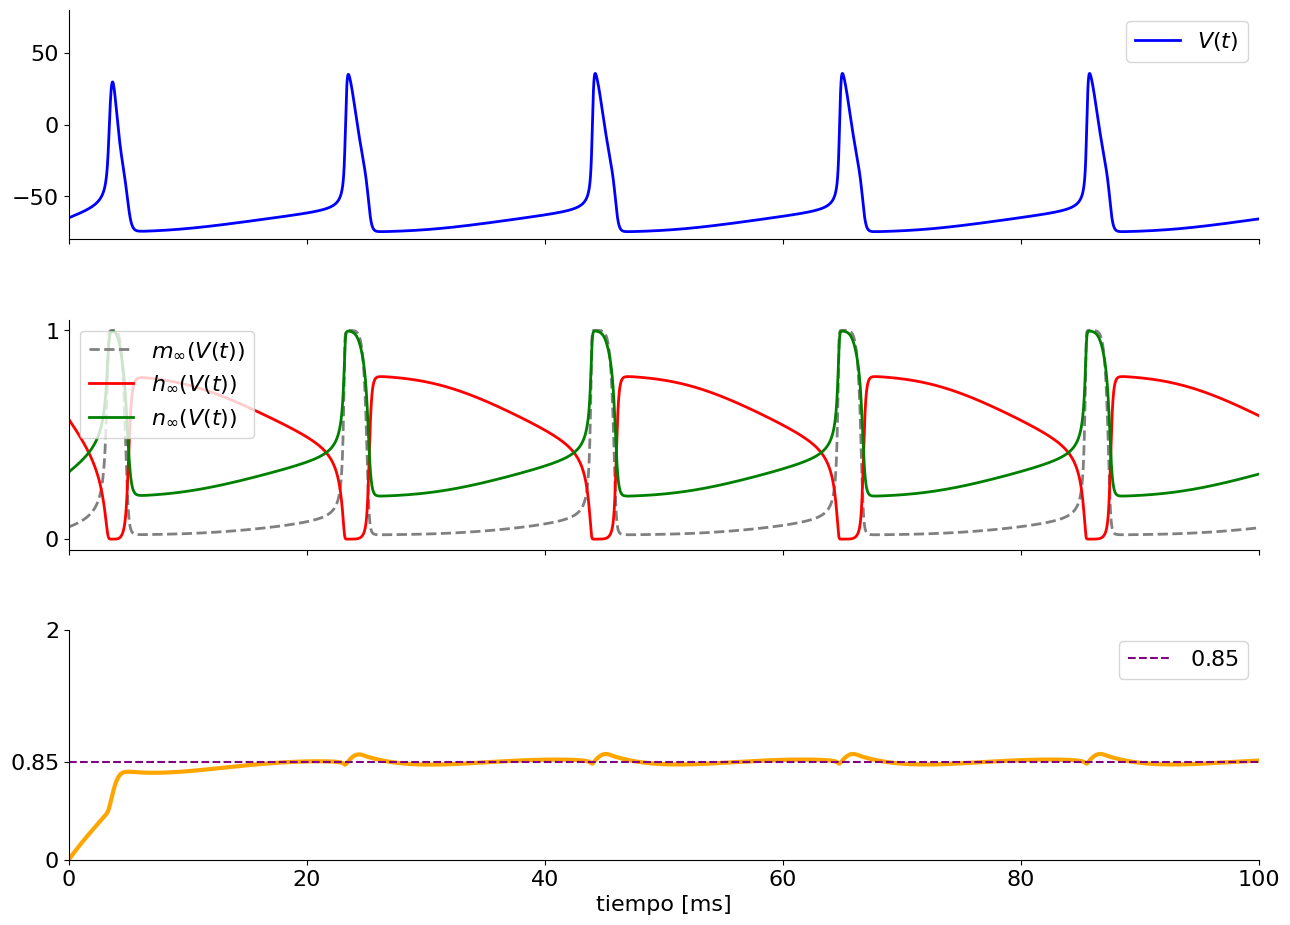

In [25]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# ======================
# Grafico del modelo completo
# ======================
axs[0].plot(t, Vo, 'b', linewidth=2, label=r'$V(t)$')
axs[0].axis([0, 100, -80, 80])
#axs[0].set_ylabel('Membrane Potential', fontsize=16)
axs[0].legend(fontsize=16, loc='upper right')
axs[0].tick_params(labelsize=16)

# ======================
# grafico de cada una de las puertas de act/inact
# ======================
axs[1].axis([0, 100, -0.05, 1.05])

axs[1].plot(t, minf(Vo),
            color='0.5',
            linestyle='--',
            linewidth=2,
            label=r'$m_{\infty}(V(t))$')

axs[1].plot(t, hinf(Vo), 'r', linewidth=2, label=r'$h_{\infty}(V(t))$')
axs[1].plot(t, ninf(Vo), 'g', linewidth=2, label=r'$n_{\infty}(V(t))$')

axs[1].set_yticks([0, 1])
axs[1].set_yticklabels([r'$0$', r'$1$'], fontsize=16)
#axs[1].set_ylabel('gating variables', fontsize=16)
axs[1].legend(fontsize=16)
axs[1].tick_params(labelsize=16)

# ======================
# n + h = const
# ======================
axs[2].axis([0, 100, 0, 2])
axs[2].plot(t, var_n + var_h, 'orange', linewidth=3)

alpha = np.mean(var_n + var_h)
axs[2].axhline(y=alpha, color='purple', linestyle='--',
               label=rf'${alpha:.2f}$')

axs[2].set_yticks([0, alpha, 2])
axs[2].set_yticklabels([r'$0$', rf'${alpha:.2f}$', r'$2$'], fontsize=16)

axs[2].set_xlabel('tiempo [ms]', fontsize=16)
#axs[2].set_ylabel(r'$n(t)+h(t)$', fontsize=16)
axs[2].legend(fontsize=16)
axs[2].tick_params(labelsize=16)

# ======================
# AJUSTES IMPORTANTES
# ======================
plt.subplots_adjust(
    left=0.12,    # más espacio para labels Y
    right=0.97,
    top=0.97,
    bottom=0.12,  # más espacio para time [ms]
    hspace=0.35   # separación vertical entre paneles
)

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)

plt.show()


## Proyección en el plano $(n,h)$

Se representa la trayectoria del sistema completo en el plano de las variables de compuerta $(n,h)$.

Se observa que la dinámica se organiza aproximadamente sobre una recta de pendiente negativa, lo que indica que la suma $n(t) + h(t)$ se mantiene casi constante a lo largo del tiempo. Esta relación se ilustra mediante la recta $n + h = \alpha$, donde $\alpha$ corresponde al valor medio de dicha suma.

Este comportamiento sugiere que las variables $n$ y $h$ no evolucionan de manera independiente, lo que permite reducir la dimensionalidad del sistema expresando una en función de la otra.


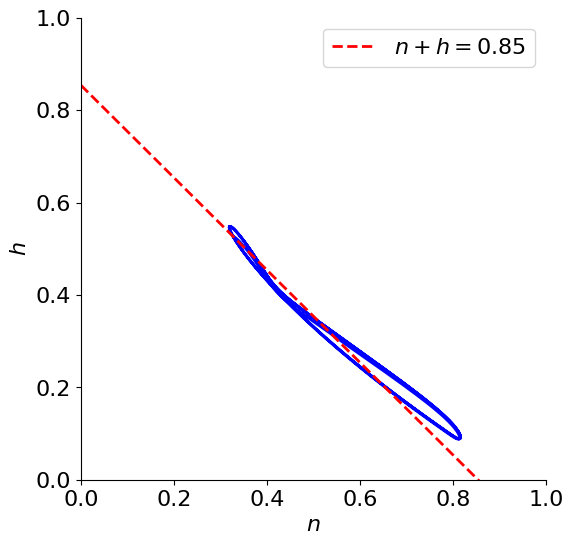

In [26]:
# Grafico de la proyeccion nh
plt.figure(figsize=(6, 6))

plt.plot(var_n[2000:9000], var_h[2000:9000],
         color='blue', linewidth=2)

x = np.linspace(0, 1, 200)
m = -1
b = np.mean(var_n + var_h)
y = m*x + b

plt.plot(x, y, '--r', linewidth=2, label=rf'$n+h = {b:.2f}$')

plt.axis([0, 1, 0, 1])
plt.xlabel(r'$n$', fontsize=16)
plt.ylabel(r'$h$', fontsize=16)

plt.legend(fontsize=16)
plt.tick_params(labelsize=16)
#plt.grid(True)

# Quito borde superior y borde derecho
ax = plt.gca()  
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.show()



## Comparación entre el modelo completo y el modelo reducido

Se simula el modelo reducido de dos variables, obtenido a partir de la aproximación $h \approx \alpha - n$, y se compara su dinámica con la del modelo completo.

En la figura se muestra la evolución temporal del potencial de membrana para ambos modelos. Se observa que el modelo reducido reproduce de manera adecuada los spikes y la dinámica general del sistema original.

Este resultado valida la reducción realizada, indicando que la dinámica esencial del sistema puede capturarse con un número menor de variables.


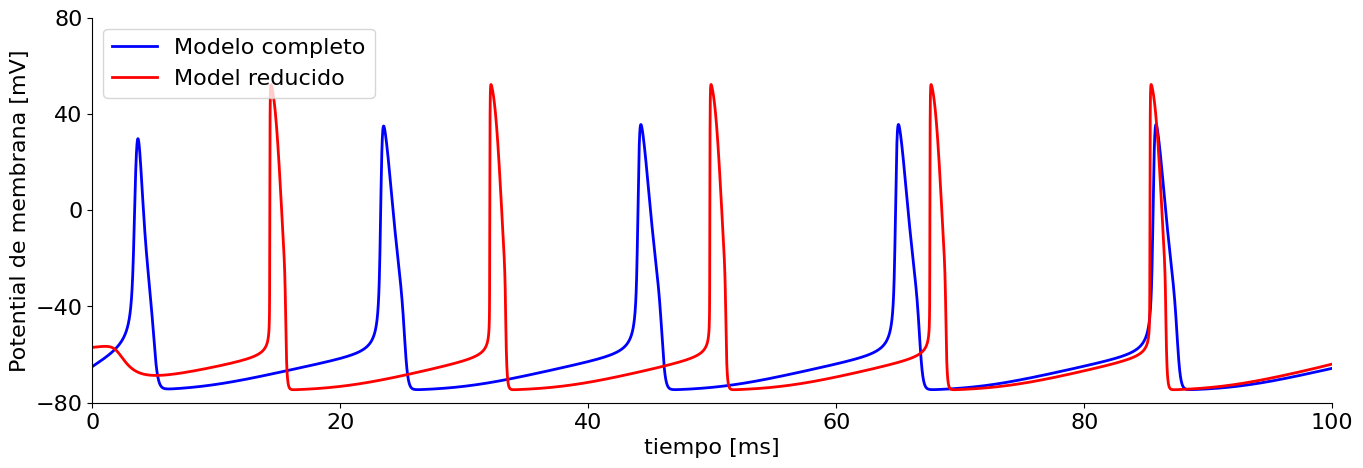

In [27]:
# Derivadas del sistema
def reduced_model_deriv(state, t):
    V, n = state
    dVdt = (Iapp - Gl * (V - El) - Gna * minf(V)**3 * (alpha - n) * (V - Ena) - Gk * n**4 * (V - Ek)) / C
    dndt = (ninf(V) - n) / taun(V)
    return np.array([dVdt, dndt])

Y_red = np.zeros((len(t), 2))  # columnas: V, n
Y_red[0, :] = [-57, 0.4]  # condiciones iniciales

for i in range(1, len(t)):
    Y_red[i] = rk4_step(reduced_model_deriv, Y_red[i-1], t[i-1], dt)


# Grafico del modelo reducido vs completo
plt.figure(figsize=(16, 5))

plt.plot(t, Vo, 'b', linewidth=2, label='Modelo completo')
plt.plot(t, Y_red[:, 0], 'r', linewidth=2, label='Model reducido')

plt.axis([0, 100, -80, 80])

plt.xlabel('tiempo [ms]', fontsize=16)
plt.ylabel('Potential de membrana [mV]', fontsize=16)

plt.yticks([-80, -40, 0, 40, 80], fontsize=16)
plt.xticks(fontsize=16)

plt.legend(fontsize=16)

# Quito borde superior y borde derecho
ax = plt.gca()  
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
